# Differentiable QP — a simple 2D example

This notebook shows how to differentiate through a QP with cuPIQP. We use a two-dimensional parameter so we can visualize the loss and its gradient over the $(c_1, c_2)$ plane. We work out, in detail, **how the gradient is computed by reverse-mode differentiation** — deriving the vector–Jacobian product (VJP) through the chain rule — and then check the solver's `backward()` against a closed-form reference.

## Problem formulation

We consider a QP with a vector variable $x\in\mathbb{R}^2$ and box constraints:

$$\min_x \; \tfrac{1}{2}\, x^\top x + c^\top x \quad \text{s.t.} \quad -\mathbf{1} \le x \le \mathbf{1}$$

parameterized by $c\in\mathbb{R}^2$ (so $P = I$). Because the cost and the box both decouple across coordinates, the optimal solution is componentwise clipping:

$$x^\star(c) = \operatorname{clip}(-c,\,-1,\,1), \qquad x_i^\star = \operatorname{clip}(-c_i,\,-1,\,1), \quad i = 1, 2.$$

We attach an **outer loss**

$$\ell(c) = \tfrac{1}{2}\,\lVert x^\star(c) \rVert^2 = \tfrac{1}{2}\big( x_1^{\star 2} + x_2^{\star 2} \big),$$

and our goal is its gradient $\nabla_c\,\ell$. The next section derives that gradient through the chain rule; here we just record the closed form we will check against — each coordinate $i$ depends only on $c_i$:

$$(\nabla_c\,\ell)_i = \begin{cases} c_i & |c_i| < 1 \quad (\text{interior: } x_i^\star = -c_i) \\ 0 & |c_i| > 1 \quad (\text{saturated: } x_i^\star \text{ pinned to a bound}). \end{cases}$$

**Notice** that along the lines $c_i = \pm 1$ the active set changes and $\nabla_c\,\ell$ is undefined (only a subgradient exists), so the grid samples *around* those lines, never on them.

## Analytical solution

We plot the closed-form loss $\ell(c)$ over the $(c_1, c_2)$ plane in two ways: a 3-D surface, with $c_1, c_2$ on the horizontal axes and $\ell$ on the vertical axis, and a heatmap overlaid with the descent field $-\nabla_c\,\ell$ (arrows). The dotted lines mark $c_i = \pm 1$, where the active set changes.

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from cupiqp import DenseSolver, Status

# Grid over (c1, c2) in [-2.5, 2.5]^2. An EVEN count avoids the kink lines
# c_i = +/-1 (where the gradient is undefined) instead of landing on them.
c_axis = np.linspace(-2.5, 2.5, 50)                    # c values along each axis
C1, C2 = np.meshgrid(c_axis, c_axis, indexing='xy')
c_grid = np.stack([C1.ravel(), C2.ravel()], axis=1)    # (B, 2)
B, n = c_grid.shape
grid_side = c_axis.size                                # points per axis (grid is grid_side x grid_side)

# Closed-form references (componentwise).
x_analytic    = np.clip(-c_grid, -1.0, 1.0)                 # x*(c)        (B, 2)
loss_analytic = 0.5 * np.sum(x_analytic**2, axis=1)         # l(c)         (B,)
grad_analytic = np.where(np.abs(c_grid) < 1.0, c_grid, 0.0) # grad_c l     (B, 2)

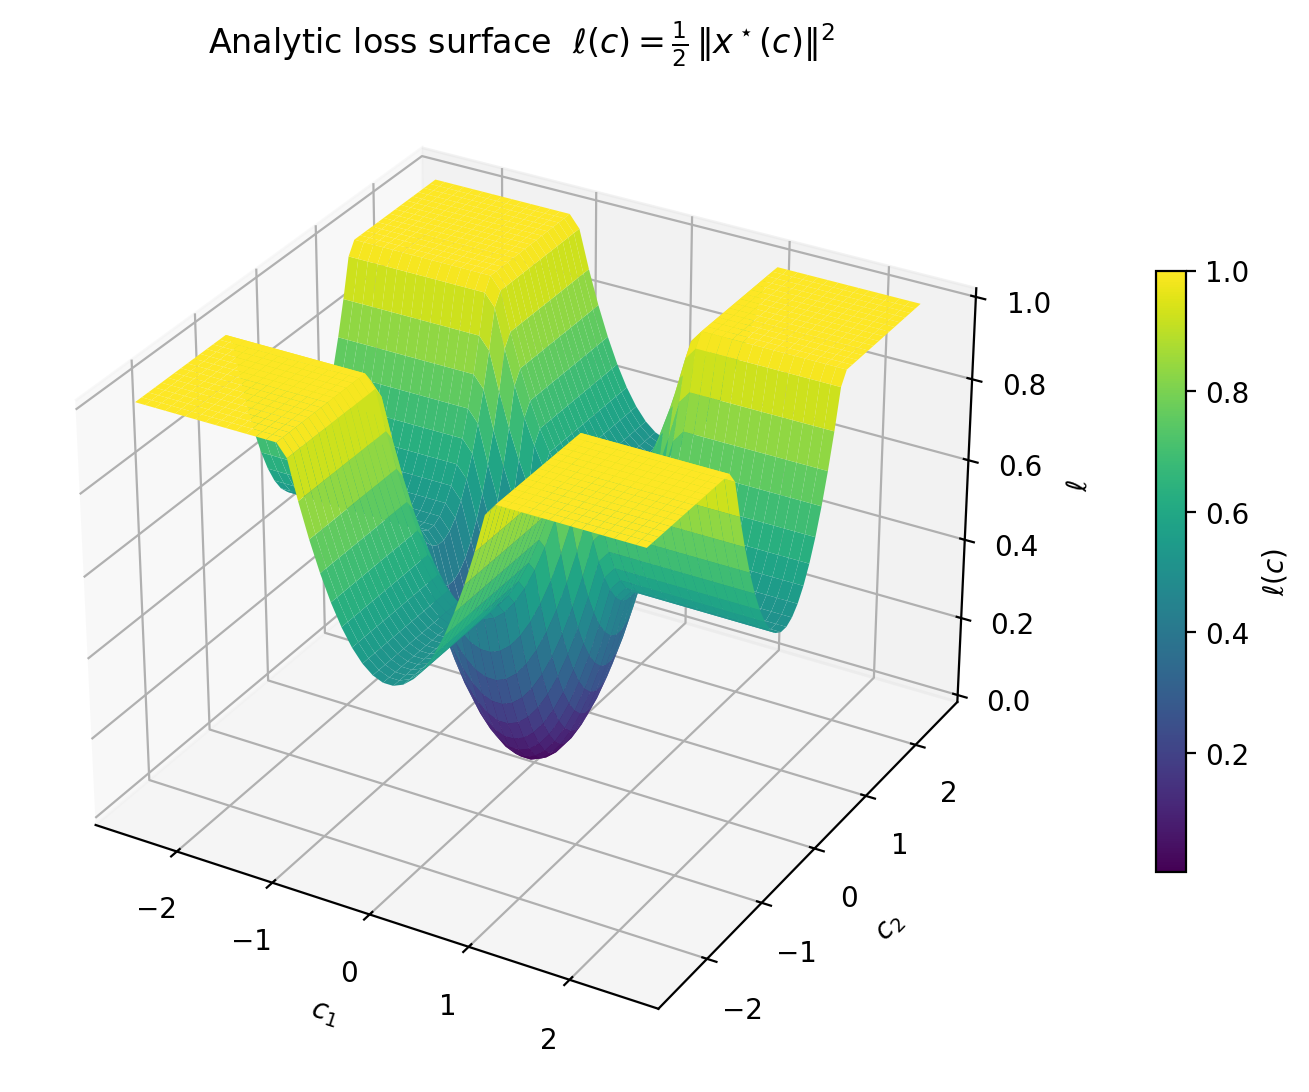

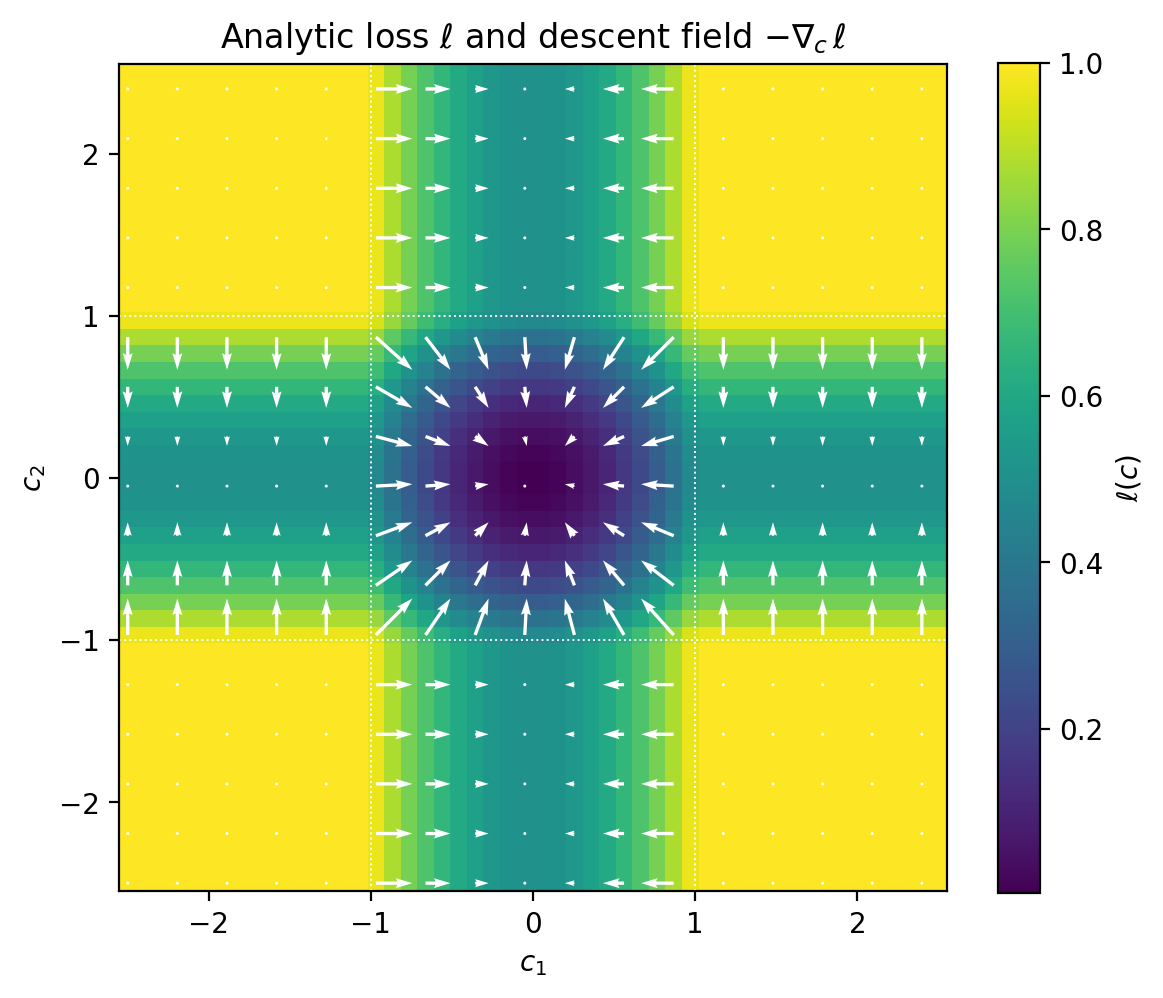

In [2]:
loss_analytic_grid  = loss_analytic.reshape(grid_side, grid_side)
grad1_analytic_grid = grad_analytic[:, 0].reshape(grid_side, grid_side)
grad2_analytic_grid = grad_analytic[:, 1].reshape(grid_side, grid_side)

# 3-D view of the analytic loss surface: (c1, c2) on the floor, loss on z.
fig = plt.figure(figsize=(7, 5.5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(C1, C2, loss_analytic_grid, cmap='viridis',
                       linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label=r'$\ell(c)$')
ax.set_xlabel('$c_1$'); ax.set_ylabel('$c_2$'); ax.set_zlabel(r'$\ell$')
ax.set_title(r'Analytic loss surface  $\ell(c) = \frac{1}{2}\,\|x^\star(c)\|^2$')
ax.view_init(elev=30, azim=-60)
plt.tight_layout()
plt.show()

# 2-D heatmap of the loss with the descent field -grad_c l overlaid.
step = 3   # subsample arrows for readability
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(C1, C2, loss_analytic_grid, shading='auto', cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$\ell(c)$')
ax.quiver(C1[::step, ::step], C2[::step, ::step],
          -grad1_analytic_grid[::step, ::step], -grad2_analytic_grid[::step, ::step],
          color='w', scale=22, width=0.004)
for v in (-1.0, 1.0):                       # mark the kink lines c_i = +/-1
    ax.axvline(v, color='w', lw=0.7, ls=':')
    ax.axhline(v, color='w', lw=0.7, ls=':')
ax.set_xlabel('$c_1$'); ax.set_ylabel('$c_2$'); ax.set_aspect('equal')
ax.set_title(r'Analytic loss $\ell$ and descent field $-\nabla_c\,\ell$')
plt.tight_layout()
plt.show()

Notice that the flat regions where $|c_1|>1$ and $|c_2|>1$ indicate that $\nabla_c \ell = 0$  because $\ell$ does not change as $c$ varies.

## Reverse-mode differentiation and the VJP

**Gradient convention.** For a scalar $\ell$ and a vector $v\in\mathbb{R}^k$, the derivative $\dfrac{\partial \ell}{\partial v}$ is a *row* vector (a $1\times k$ Jacobian). We define the **gradient** as its transpose,

$$\nabla_v\,\ell \;:=\; \Big(\frac{\partial \ell}{\partial v}\Big)^{\!\top} \in \mathbb{R}^k。$$

**Chain rule.** Our computation is the composition

$$c \;\longmapsto\; x^\star(c) \;\longmapsto\; \ell = \tfrac{1}{2}\lVert x^\star\rVert^2 .$$

Differentiating with the ordinary (forward) chain rule on Jacobians,

$$\frac{\partial \ell}{\partial c} \;=\; \frac{\partial \ell}{\partial x^\star} \frac{\partial x^\star}{\partial c}.$$

Taking the transpose of both sides and applying the convention above,

$$\;\nabla_c\,\ell \;=\; \Big(\frac{\partial x^\star}{\partial c}\Big)^{\!\top}\Big(\frac{\partial \ell}{\partial x^\star}\Big)^{\!\top} \;=\; \Big(\frac{\partial x^\star}{\partial c}\Big)^{\!\top}\,\nabla_{x^\star}\ell\;$$

The right-hand side is a **vector–Jacobian product (VJP)**: the transposed solution Jacobian $\big(\partial x^\star/\partial c\big)^{\top}$ applied to the single vector $\nabla_{x^\star}\ell$. Reverse mode never forms the full $n\times n$ Jacobian — it only needs this product. 

This is exactly what cuPIQP's `backward()` method does.

**What `backward` returns.** `solver.backward(grad_x = ∇_{x*}ℓ)` takes the upstream gradient $\nabla_{x^\star}\ell$ and returns $\nabla_c\,\ell$ in its `.c` field (and $\nabla_P\,\ell$, $\nabla_A\,\ell$, … for the other data). The transposed solution Jacobian is obtained by implicitly differentiating the KKT optimality conditions; applying it to a vector is **one solve with the KKT matrix that was already factored during the forward pass**, so the VJP costs essentially a single back-substitution.

For the loss in this example $\ell = \tfrac{1}{2}\lVert x^\star\rVert^2$, we have $\nabla_{x^\star}\ell = x^\star$, so we simply pass the solver's own solution $x^\star$ as `grad_x`.

## Numerical solution

Now we solve and differentiate the QP using cuPIQP and compare with the closed forms above.

Enable differentiation by setting `solver.settings.enable_grad = True` (the default is `False`). Following the VJP derived above, we pass the upstream gradient $\nabla_{x^\star}\ell = x^\star$ as `grad_x` in the `backward()` method, which $\nabla_c\,\ell$ in its `.c` field.

We place one QP at every grid point and solve all $50 \times 50 = 2500$ of them in a single batched call — the batch is the leading dimension throughout cuPIQP.

In [3]:
# One 2-D QP per grid point:  min 0.5 x^T x + c^T x   s.t.  -1 <= x <= 1.
P_cp  = cp.tile(cp.eye(n), (B, 1, 1))            # P = I for every problem (B, 2, 2)
c_cp  = cp.asarray(c_grid)                        # (B, 2)
xl_cp = cp.full((B, n), -1.0, dtype=cp.float64)
xu_cp = cp.full((B, n),  1.0, dtype=cp.float64)

solver = DenseSolver()
solver.settings.enable_grad = True   # enable backward()
solver.settings.verbose = True

solver.setup(P=P_cp, c=c_cp, x_l=xl_cp, x_u=xu_cp)
solver.solve()

# All problems should converge -- assert it so the notebook is self-checking.
n_unsolved = sum(st != Status.CUPIQP_SOLVED for st in solver.result.info.status)
assert n_unsolved == 0, f'{n_unsolved} QP(s) failed to converge'
print(f'\nAll {B} QPs solved  (max iterations used: {int(solver.result.info.iter.max())})')

----------------------------------------------------------
       cuPIQP v0.1.0 - GPU-accelerated PIQP solver        
                    (c) Fenglong Song                     
   Ecole Polytechnique Federale de Lausanne (EPFL) 2026   
----------------------------------------------------------
dense backend:
variables n = 2
equality constraints p = 0
inequality constraints m = 0
inequality lower bounds n_h_l = 0
inequality upper bounds n_h_u = 0
variable lower bounds n_x_l = 2
variable upper bounds n_x_u = 2

iter     solved       gap_max     p_res_max     d_res_max     rho_max   delta_max      mu_max  p_step  d_step
   0     0/2500   2.77787e+00   5.11659e-01   1.66661e+00   1.000e-06   1.000e-04   3.471e-01  0.0000  0.0000
   1     0/2500   2.99831e+00   1.08159e-01   1.50168e+00   1.000e-07   1.000e-05   1.542e-01  0.0990  0.9579
   2     0/2500   2.90429e+00   3.80119e-02   1.45219e+00   5.000e-08   5.000e-06   3.787e-02  0.0011  0.9864
   3     0/2500   2.87373e+03   3.80118e-04  

Now we verify the consistency of the numerical results obtained through cuPIQP with the analytical ones.

In [4]:
# VJP:  grad_c l = (dx*/dc)^T @ grad_{x*} l,  with grad_{x*} l = x*  for  l = 1/2||x*||^2.
x_star    = solver.result.x                    # (B, 2)
grad_data = solver.backward(grad_x=x_star)

# Bring results back to CPU.
x_numeric    = cp.asnumpy(x_star)               # x*(c)      (B, 2)
grad_numeric = cp.asnumpy(grad_data.c)          # grad_c l   (B, 2)
loss_numeric = 0.5 * np.sum(x_numeric**2, axis=1)  # l(c)    (B,)

# Check the difference with analytic solutions across the whole grid.
print()
print(f'max |x*:     numeric - analytic| = {np.abs(x_numeric    - x_analytic   ).max():.2e}')
print(f'max |loss:   numeric - analytic| = {np.abs(loss_numeric - loss_analytic).max():.2e}')
print(f'max |dldc:   numeric - analytic| = {np.abs(grad_numeric - grad_analytic).max():.2e}')


max |x*:     numeric - analytic| = 2.78e-07
max |loss:   numeric - analytic| = 2.90e-07
max |dldc:   numeric - analytic| = 8.90e-06


## Visualization

Three panels:
1. **Solver loss + descent field** — the same view as the analytic preview, now built from the solver's `backward()` output; it should look identical.
2. **Gradient magnitude $\lVert\nabla_c\,\ell\rVert$** — bright in the interior, going to **zero in the dead zones** (outside the dotted square). The diamond-shaped boundary is where coordinates saturate.
3. **Error map** — $\lVert\nabla_c\,\ell^{\text{(numeric)}} - \nabla_c\,\ell^{\text{(exact)}}\rVert$ across the plane, confirming the VJP matches the closed form everywhere.

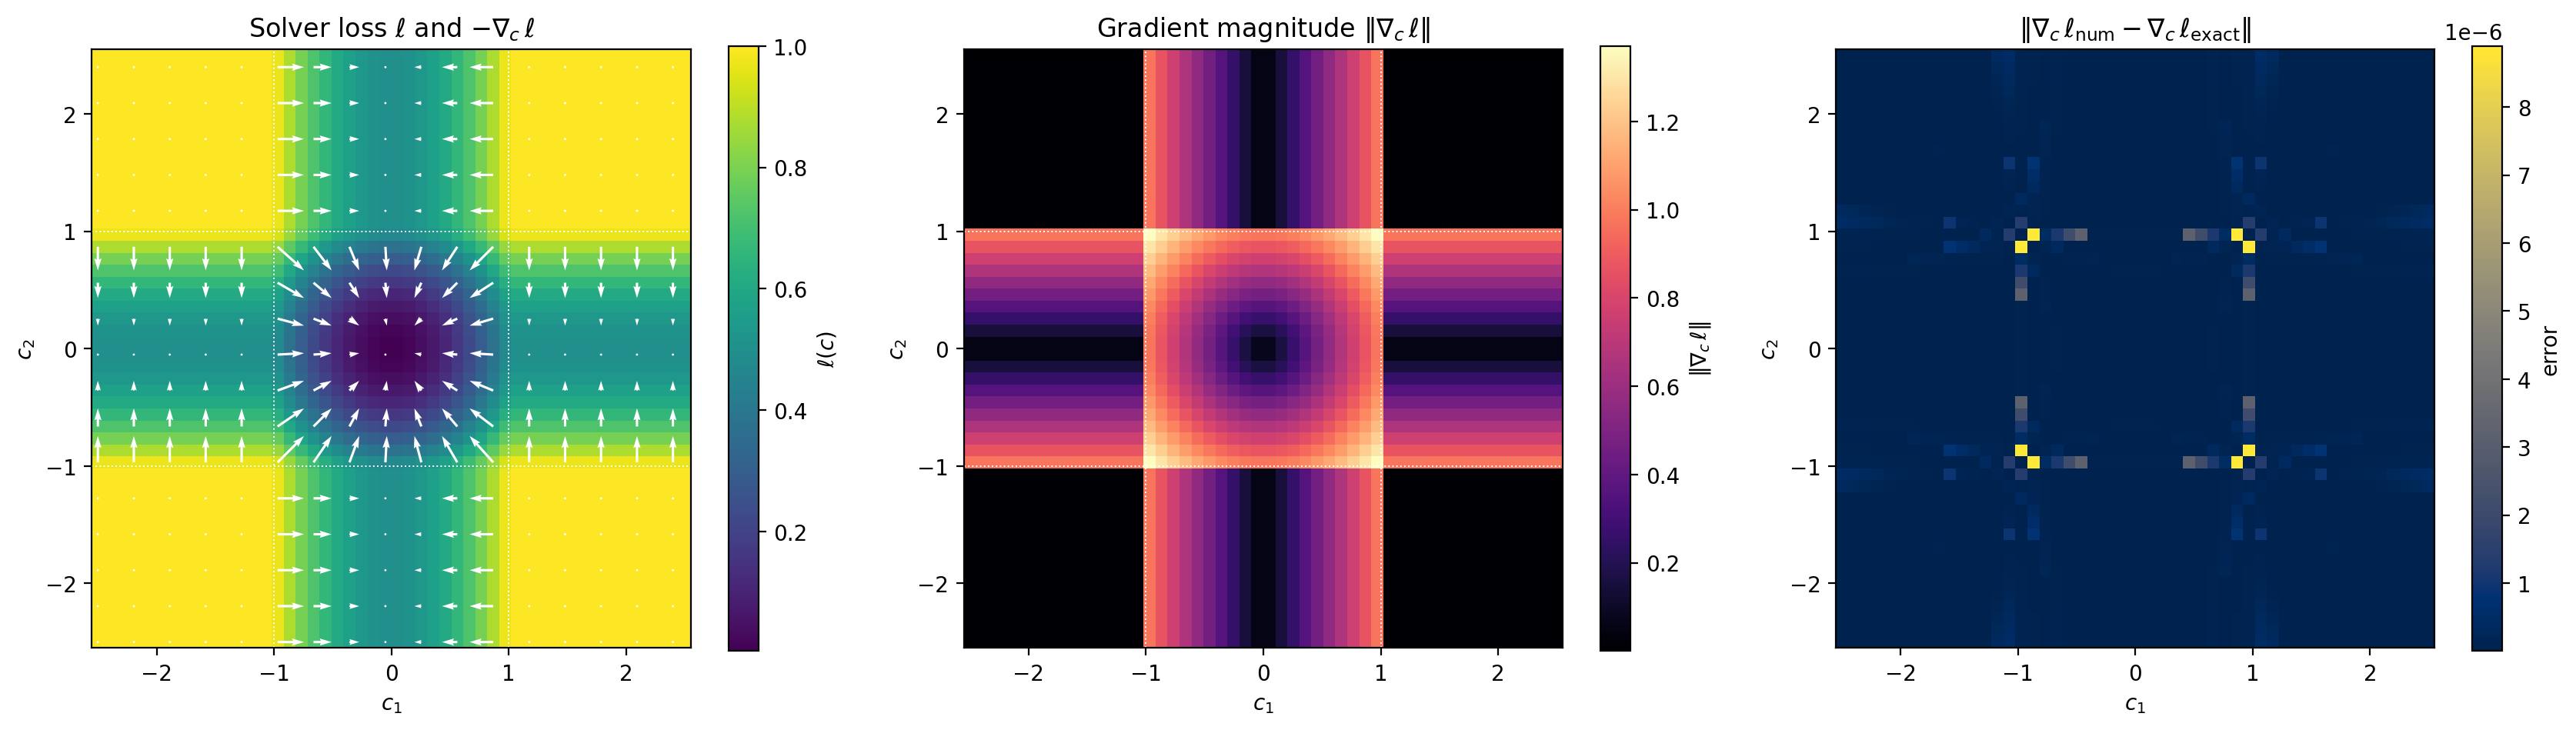

In [5]:
loss_numeric_grid  = loss_numeric.reshape(grid_side, grid_side)
grad1_numeric_grid = grad_numeric[:, 0].reshape(grid_side, grid_side)
grad2_numeric_grid = grad_numeric[:, 1].reshape(grid_side, grid_side)
grad_mag_grid = np.linalg.norm(grad_numeric, axis=1).reshape(grid_side, grid_side)
err_grid      = np.linalg.norm(grad_numeric - grad_analytic, axis=1).reshape(grid_side, grid_side)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# --- panel 1: solver loss + descent field ---
ax = axes[0]
im = ax.pcolormesh(C1, C2, loss_numeric_grid, shading='auto', cmap='viridis')
fig.colorbar(im, ax=ax, label=r'$\ell(c)$')
step = 3   # subsample arrows for readability
ax.quiver(C1[::step, ::step], C2[::step, ::step],
          -grad1_numeric_grid[::step, ::step], -grad2_numeric_grid[::step, ::step],
          color='w', scale=22, width=0.004)
for v in (-1.0, 1.0):
    ax.axvline(v, color='w', lw=0.7, ls=':'); ax.axhline(v, color='w', lw=0.7, ls=':')
ax.set_xlabel('$c_1$'); ax.set_ylabel('$c_2$'); ax.set_aspect('equal')
ax.set_title(r'Solver loss $\ell$ and $-\nabla_c\,\ell$')

# --- panel 2: gradient magnitude (dead zones -> 0) ---
ax = axes[1]
im = ax.pcolormesh(C1, C2, grad_mag_grid, shading='auto', cmap='magma')
fig.colorbar(im, ax=ax, label=r'$\|\nabla_c\,\ell\|$')
for v in (-1.0, 1.0):
    ax.axvline(v, color='w', lw=0.7, ls=':'); ax.axhline(v, color='w', lw=0.7, ls=':')
ax.set_xlabel('$c_1$'); ax.set_ylabel('$c_2$'); ax.set_aspect('equal')
ax.set_title(r'Gradient magnitude $\|\nabla_c\,\ell\|$')

# --- panel 3: numeric-vs-analytic error ---
ax = axes[2]
im = ax.pcolormesh(C1, C2, err_grid, shading='auto', cmap='cividis')
fig.colorbar(im, ax=ax, label='error')
ax.set_xlabel('$c_1$'); ax.set_ylabel('$c_2$'); ax.set_aspect('equal')
ax.set_title(r'$\|\nabla_c\,\ell_{\mathrm{num}} - \nabla_c\,\ell_{\mathrm{exact}}\|$')

plt.tight_layout()
plt.show()